# El problema de la detección de cheques bancarios falsos

En este cuaderno exploraremos el flujo completo de un proyecto de aprendizaje automático: desde la lectura de datos hasta la validación de modelos, utilizando el clásico conjunto de datos <b>Bank note authentication dataset</b> .

Nuestro objetivo será predecir si un cheque bancario es falso o verdadero.

Más info en:

<a href="https://archive.ics.uci.edu/dataset/267/banknote+authentication">https://archive.ics.uci.edu/dataset/267/banknote+authentication</a>

Se recomienda:

1. Mirar el cuaderno de la flor de Iris.
1. Seguir el procedimiento general:
1.1. Lectura de datos.
1.2. Análisis exploratorio de datos.
1.3. Preprocesamiento de datos.
1.4. Modelado.
1.5. Evaluación.

*Los métodos usados en el cuaderno del Iris no tienen porqué ser (ni porqué no ser) los mismos que los necesarios para usar en este cuaderno.

In [86]:
# Importación de librerías esenciales
import numpy as np
import matplotlib.pyplot as plt
import pandas as pd

# Herramientas de scikit-learn
from sklearn.preprocessing import StandardScaler, LabelEncoder
from sklearn.model_selection import train_test_split, KFold, cross_val_score
from sklearn.feature_selection import SelectKBest, f_classif
from sklearn.decomposition import PCA
from sklearn.linear_model import LogisticRegression
from sklearn.tree import DecisionTreeClassifier
from sklearn.metrics import accuracy_score, confusion_matrix, ConfusionMatrixDisplay

## 1. Lectura de Datos
Utilizaremos `pandas` exclusivamente para descargar y leer nuestro conjunto de datos en formato CSV desde un repositorio público.

In [87]:
# URL pública con el dataset
# url = "https://raw.githubusercontent.com/mwaskom/seaborn-data/master/iris.csv"
# url = "https://raw.githubusercontent.com/jbrownlee/Datasets/blob/master/banknote_authentication.csv"
url= "https://raw.githubusercontent.com/jbrownlee/Datasets/master/banknote_authentication.csv"
# Lectura del CSV

# EL fichero de este dataset no tiene cabeceras
df = pd.read_csv(url, header=None)

# Se las tenemos que poner nosotros
headers= ['variance', 'skewness', 'curtosis', 'entropy', 'class']
df.columns = headers


# Algunas muestras del dataset
df.sample(10)

,variance,skewness,curtosis,entropy,class
28,6.56330,9.8187,-4.41130,-3.22580,0
208,2.10590,7.6046,-0.47755,-1.84610,0
611,3.81970,8.9951,-4.38300,-4.03270,0
1074,-0.41965,2.9094,-1.78590,-2.20690,1
1242,-3.60530,-5.9740,10.09160,-0.82846,1
139,-0.20620,9.2207,-3.70440,-6.81030,0
1125,-3.59850,-13.6593,17.60520,-2.49270,1
201,4.00260,-3.5943,3.55730,0.26809,0
562,-2.46040,12.7302,0.91738,-7.64180,0
1192,-4.40180,-12.9371,15.65590,-1.68060,1


In [88]:
# Extraemos las características (X) y las etiquetas (y) como arreglos de numpy
X_raw = df[['variance', 'skewness', 'curtosis', 'entropy']].values
Y_raw = df['class'].values

print("Dimensiones de X: {} datos y {} atributos/dato".format(X_raw.shape[0], X_raw.shape[1]))

etiquetas= np.unique(Y_raw)

print("La última columna tiene las clases:\nHay {} tipos de clase: {}".format(len(etiquetas), etiquetas))

Dimensiones de X: 1372 datos y 4 atributos/dato
La última columna tiene las clases:
Hay 2 tipos de clase: [0 1]


In [89]:
print('Información básica del dataset: ')
df.info()

Información básica del dataset: 
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 1372 entries, 0 to 1371
Data columns (total 5 columns):
 #   Column    Non-Null Count  Dtype  
---  ------    --------------  -----  
 0   variance  1372 non-null   float64
 1   skewness  1372 non-null   float64
 2   curtosis  1372 non-null   float64
 3   entropy   1372 non-null   float64
 4   class     1372 non-null   int64  
dtypes: float64(4), int64(1)
memory usage: 53.7 KB


In [90]:
print('Estadísticos básicos: ')
df.describe()

Estadísticos básicos: 


,variance,skewness,curtosis,entropy,class
count,1372.000000,1372.000000,1372.000000,1372.000000,1372.000000
mean,0.433735,1.922353,1.397627,-1.191657,0.444606
std,2.842763,5.869047,4.310030,2.101013,0.497103
min,-7.042100,-13.773100,-5.286100,-8.548200,0.000000
25%,-1.773000,-1.708200,-1.574975,-2.413450,0.000000
50%,0.496180,2.319650,0.616630,-0.586650,0.000000
75%,2.821475,6.814625,3.179250,0.394810,1.000000
max,6.824800,12.951600,17.927400,2.449500,1.000000


## 2. Análisis Exploratorio de Datos (EDA)
Antes de entrenar cualquier modelo, debemos entender nuestros datos. Visualiza cómo se distribuyen las clases con respecto a los atributos, mira si hay valores perdidos, los estadísticos básicos de cada atributo, etc.

También conviene ver si el problema está balanceado (hay más o menos el mismo número de datos de cheques falsos que de cheques verdaderos). Un diagrama de quesos puede ayudar.

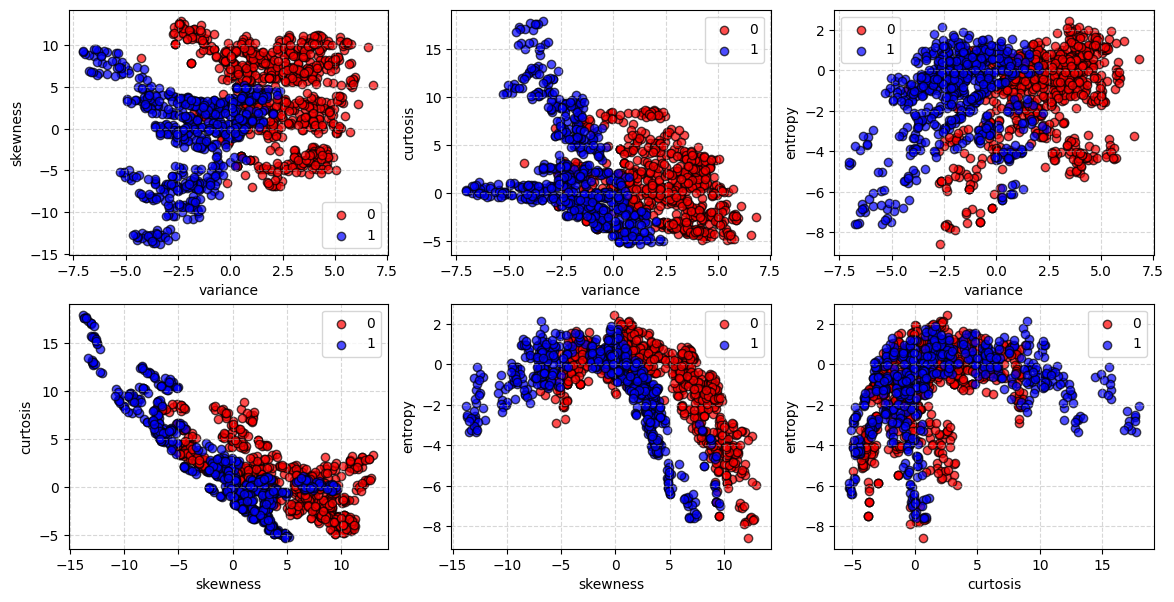

In [91]:
from itertools import combinations

clases= df['class'].unique()
colores= ['red', 'blue']

columnas= df.columns[:-1] # Sólo atributos
columnas_idx= np.arange(len(columnas)) # Índices de las columnas

# Combinaciones de todas con todas las columnas (sin permutar)
plt.figure(figsize=(14, 7))
for i, (col1, col2) in enumerate(combinations(columnas_idx, 2), 1):
  plt.subplot(2, 3, i) # Cada par (col1, col2) a un subplot
  for clase, color in zip(clases, colores):
    idx = (Y_raw == clase)
    plt.scatter(X_raw[idx, col1], X_raw[idx, col2], label=clase, color=color, alpha=0.7, edgecolors='k')

    plt.xlabel(columnas[col1])
    plt.ylabel(columnas[col2])
    plt.legend()
    plt.grid(True, linestyle='--', alpha=0.5) # Ponerlo "bonito"
plt.show()


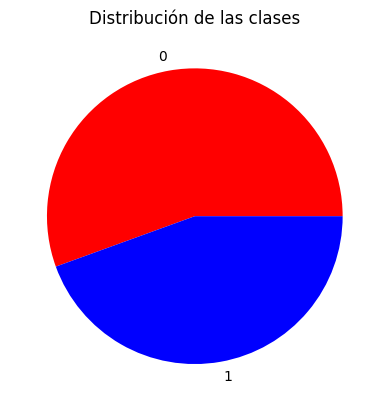

In [92]:
plt.title('Distribución de las clases')
plt.pie([Y_raw[Y_raw==0].size, Y_raw[Y_raw==1].size], labels=clases, colors=colores); # <- El ; es para evitar salida indeseada por consola

## 3. Preprocesamiento de Datos


Si hay valores perdidos, decide qué hacer con ellos.

Haz que todos los atributos sean del tipo que necesitas, en el rango que necesitas (MinMaxScaler/StandardScaler/ambos/ninguno, etc.), para poder resolver mejor el problema.

Divide el problema en train/test. Una proporción 70/30 suele ser lo común (a veces 50/50, si hay suficientes datos). Si el problema no está balanceado, asegúrate de que tanto train como test tengan la misma proporción de cada clase.


Se nos pide aplicar las siguientes transformaciones:
1. Transformar a $[0,1]$
2. Extraer $x_s = \sqrt{variance + skewness}$
3. visualizar $x_s$ vs curtosis

In [93]:
import numpy as np
from sklearn.preprocessing import LabelEncoder, MinMaxScaler

# # Cambio de rango a [0,1] con MinMaxScaler de cada columna
mme= MinMaxScaler(feature_range=(0,1))
dt = mme.fit_transform(df) # Datos transformados

print('\nCambio de rango a [0,1] con MinMaxScaler:')
dt = pd.DataFrame(dt, columns=df.columns)
dt.sample(10)



Cambio de rango a [0,1] con MinMaxScaler:


,variance,skewness,curtosis,entropy,class
751,0.670424,0.818430,0.217000,0.479955,0.0
381,0.898607,0.895007,0.051785,0.440919,0.0
586,0.619295,0.835231,0.245754,0.579194,0.0
59,0.451378,0.940456,0.211500,0.136274,0.0
1138,0.320620,0.165543,0.649635,0.751795,1.0
1032,0.519632,0.389703,0.286945,0.900652,1.0
363,0.710115,0.536972,0.285545,0.887595,0.0
534,0.855988,0.805730,0.122213,0.666194,0.0
610,0.490809,0.864189,0.319504,0.379070,0.0
116,0.788857,0.792877,0.149120,0.790008,0.0


In [94]:
dt['xs'] = np.sqrt(dt['variance'] + dt['skewness'])

print('Extracción de x_s')
dt.sample(10)

Extracción de x_s


,variance,skewness,curtosis,entropy,class,xs
870,0.367768,0.529462,0.172154,0.702294,1.0,0.947222
435,0.595367,0.844601,0.134357,0.709819,0.0,1.199987
917,0.620557,0.548896,0.142844,0.836804,1.0,1.081413
663,0.780412,0.391481,0.341836,0.783306,0.0,1.082540
673,0.375520,0.928224,0.364977,0.332742,0.0,1.141816
841,0.227614,0.034687,0.778935,0.492185,1.0,0.512153
391,0.661186,0.772746,0.247009,0.575193,0.0,1.197469
15,0.845077,0.388539,0.378043,0.911582,0.0,1.110683
472,0.784638,0.746807,0.139669,0.774252,0.0,1.237516
1323,0.506010,0.508865,0.222832,0.888186,1.0,1.007410


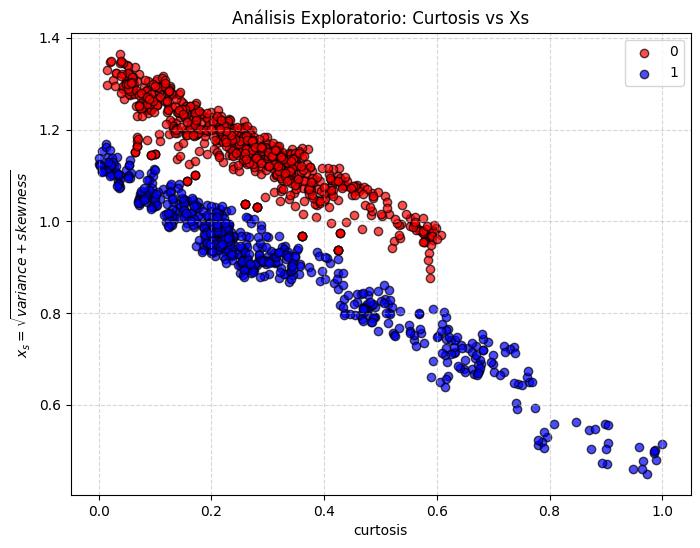

In [95]:


plt.figure(figsize=(8,6))
for clase, color in zip(clases, colores):
    # Filtramos las filas correspondientes a la especie actual
    idx = (Y_raw == clase)
    # Imprimimos columnas 2 vs 3 (características del pétalo)
    plt.scatter(dt.loc[idx, ['curtosis']], dt.loc[idx, ['xs']], label=clase, color=color, alpha=0.7, edgecolors='k')

plt.title('Análisis Exploratorio: Curtosis vs Xs')
plt.xlabel('curtosis')
plt.ylabel('$x_s = \\sqrt{variance + skewness}$')
plt.legend()
plt.grid(True, linestyle='--', alpha=0.5)
plt.show()

In [96]:

# Dividimos en conjunto de entrenamiento (70%) y prueba (30%)
Xt_raw = dt[['variance', 'skewness', 'curtosis', 'entropy', 'xs']].values
Yt_raw = dt['class'].values
X_train, X_test, y_train, y_test = train_test_split(Xt_raw, Yt_raw, test_size=0.3, random_state=42, stratify=Y_raw)

# Estandarización de datos
scaler = StandardScaler()
X_train_scaled = scaler.fit_transform(X_train)
X_test_scaled = scaler.transform(X_test) # Transformamos test con los parámetros de train

print(f"Media de X_train_scaled (por columna): {np.mean(X_train_scaled, axis=0).round(2)}")
print(f"Desviación estándar de X_train_scaled: {np.std(X_train_scaled, axis=0).round(2)}")

Media de X_train_scaled (por columna): [-0. -0.  0. -0. -0.]
Desviación estándar de X_train_scaled: [1. 1. 1. 1. 1.]


## 4. Selección vs Extracción de Características
A veces tenemos demasiadas características. Podemos reducir la dimensionalidad de dos formas:
* **Selección (SelectKBest):** Elige las mejores columnas originales.
* **Extracción (PCA):** Combina las columnas originales para crear nuevas columnas (componentes principales).

**PUEDE QUE NO HAYA QUE REALIZAR ESTE PASO**. Yo probaría a ver cómo predice un modelo que considera todos los atributos (modelo de referencia) y después iría viendo si hacer selección o extracción ayuda en algo.

In [97]:
print("--- Selección de Características (SelectKBest) ---")
# Seleccionamos las n mejores características originales
n=3

selector = SelectKBest(score_func=f_classif, k=n)
X_train_selected = selector.fit_transform(X_train_scaled, y_train)
print(f"Índices de las características seleccionadas: {selector.get_support(indices=True)}")

print("\n--- Extracción de Características (PCA) ---")
pca = PCA(n_components=n)
X_train_pca = pca.fit_transform(X_train_scaled)
print(f"Varianza explicada por los 2 componentes: {np.sum(pca.explained_variance_ratio_):.2f}")

--- Selección de Características (SelectKBest) ---
Índices de las características seleccionadas: [0 1 4]

--- Extracción de Características (PCA) ---
Varianza explicada por los 2 componentes: 0.96


## 5. Selección de Modelo y K-Fold Cross Validation
Para decidir qué algoritmo usar (Árboles de Decisión, Regresión Logística, otro), no evaluaremos en el conjunto de prueba todavía. Usaremos validación cruzada (K-Fold) sobre el conjunto de entrenamiento para ver qué modelo es más robusto.

En problemas donde las clases no están bien balanceadas, a veces es bueno cambiar el KFold por el StratifiedKFold


In [98]:
# Definimos los modelos
modelo_arbol = DecisionTreeClassifier(random_state=42)
modelo_logistico = LogisticRegression(random_state=42)

# Definimos K-Fold con 5 particiones (folds)
kfold = KFold(n_splits=5, shuffle=True, random_state=42)

# Evaluamos ambos modelos usando X_train_scaled
scores_arbol = cross_val_score(modelo_arbol, X_train_scaled, y_train, cv=kfold, scoring='accuracy')
scores_logistico = cross_val_score(modelo_logistico, X_train_scaled, y_train, cv=kfold, scoring='accuracy')

print("--- Resultados de Validación Cruzada (Precisión/Accuracy) ---")
print(f"Árbol de Decisión: {scores_arbol.mean():.4f} (+/- {scores_arbol.std():.4f})")
print(f"Regresión Logística: {scores_logistico.mean():.4f} (+/- {scores_logistico.std():.4f})")


# Classification report
from sklearn.metrics import classification_report
y_pred_arbol = modelo_arbol.fit(X_train_scaled, y_train).predict(X_train_scaled)
y_pred_logistico = modelo_logistico.fit(X_train_scaled, y_train).predict(X_train_scaled)

report_arbol= classification_report(y_pred_arbol, y_train, output_dict=True)
report_log= classification_report(y_pred_logistico, y_train, output_dict=True)


# Convertimos a DataFrame y transponemos para que las métricas sean columnas
df_arbol = pd.DataFrame(report_arbol).transpose()
print('Resultados para el árbol:')
display(df_arbol.round(2))

df_log = pd.DataFrame(report_log).transpose()
print('Resultados para regresión logística:')
display(df_log.round(2))

--- Resultados de Validación Cruzada (Precisión/Accuracy) ---
Árbol de Decisión: 0.9906 (+/- 0.0051)
Regresión Logística: 0.9844 (+/- 0.0057)
Resultados para el árbol:


,precision,recall,f1-score,support
0.0,1.0,1.0,1.0,533.0
1.0,1.0,1.0,1.0,427.0
accuracy,1.0,1.0,1.0,1.0
macro avg,1.0,1.0,1.0,960.0
weighted avg,1.0,1.0,1.0,960.0


Resultados para regresión logística:


,precision,recall,f1-score,support
0.0,0.98,1.00,0.99,522.00
1.0,1.00,0.97,0.98,438.00
accuracy,0.99,0.99,0.99,0.99
macro avg,0.99,0.99,0.99,960.00
weighted avg,0.99,0.99,0.99,960.00


## 6. Entrenamiento Final y Validación en Test
Supongamos que un modelo resultó ligeramente superior o más estable. Ahora entrenaremos este modelo final con **todos** los datos de entrenamiento y lo evaluaremos con los datos de prueba que guardamos celosamente al principio.


Precisión final en el conjunto de prueba: 99.76%



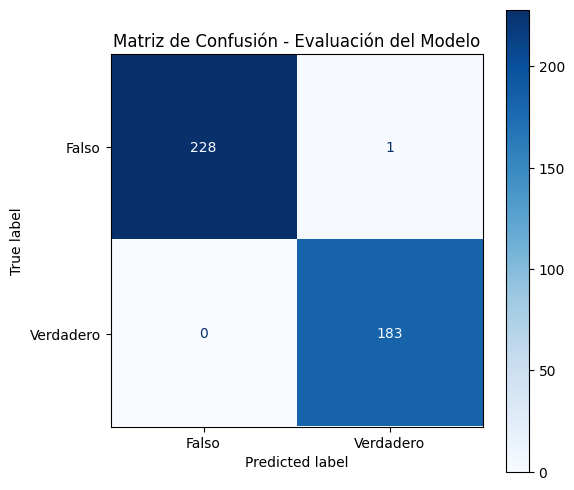

Report de arbol:


,precision,recall,f1-score,support
0.0,1.0,1.00,1.0,228.0
1.0,1.0,0.99,1.0,184.0
accuracy,1.0,1.00,1.0,1.0
macro avg,1.0,1.00,1.0,412.0
weighted avg,1.0,1.00,1.0,412.0


In [99]:
# Entrenamiento final
modelo_final = DecisionTreeClassifier(random_state=42)
modelo_final.fit(X_train_scaled, y_train)

# Predicción sobre el conjunto de prueba
y_pred = modelo_final.predict(X_test_scaled)

# Validación (Métricas)
precision_final = accuracy_score(y_test, y_pred)
print(f"Precisión final en el conjunto de prueba: {precision_final * 100:.2f}%\n")

# Matriz de Confusión
cm = confusion_matrix(y_test, y_pred)
disp = ConfusionMatrixDisplay(confusion_matrix=cm, display_labels=["Falso", "Verdadero"])

# Graficamos la matriz
fig, ax = plt.subplots(figsize=(6, 6))
disp.plot(ax=ax, cmap='Blues')
plt.title('Matriz de Confusión - Evaluación del Modelo')
plt.show()



# Classification report
report_final= classification_report(y_pred, y_test, output_dict=True)



# Convertimos a DataFrame y transponemos para que las métricas sean columnas
print('Report de arbol:')
df_arbol = pd.DataFrame(report_final).transpose()
display(df_arbol.round(2))
